# Группа: ИУ5-64Б

# ФИО: Земцов Сергей Алексеевич

# Вариант: 10

## Задача: №2 (Обработка пропусков)

## Набор данных: №2 (Wine dataset из sklearn)

## Доп. требование: Построить скрипичную диаграмму (violin plot) для произвольной колонки.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

 ### 1. Загрузка данных

In [20]:
wine = load_wine(as_frame=True)
df = wine.frame

print("Исходные данные (первые 5 строк):")
display(df.head())

Исходные данные (первые 5 строк):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 2. Искусственное создание пропусков
### (по примечанию к заданию)

In [19]:
np.random.seed(42)

# Количественный признак: alcohol
idx_q = np.random.choice(df.index, size=10, replace=False)
df.loc[idx_q, 'alcohol'] = np.nan

# Категориальный признак: создадим на основе alcohol
df['alcohol_cat'] = pd.cut(df['alcohol'],
                           bins=[0, 12.5, 13.5, 20],
                           labels=['low', 'medium', 'high'])

# Категориальный признак: добавим пропуски
idx_c = np.random.choice(df.index, size=5, replace=False)
df.loc[idx_c, 'alcohol_cat'] = np.nan

print("\nКоличество пропусков после создания:")
print("alcohol:", df['alcohol'].isna().sum())
print("alcohol_cat:", df['alcohol_cat'].isna().sum())


Количество пропусков после создания:
alcohol: 10
alcohol_cat: 14


### 3. Обработка пропусков

In [18]:
# Количественный признак — заполнение медианой
med = df['alcohol'].median()
df['alcohol'] = df['alcohol'].fillna(med)


# Категориальный признак — заполнение модой
mod = df['alcohol_cat'].mode()[0]
df['alcohol_cat'] = df['alcohol_cat'].fillna(mod)

print("\nПропусков после обработки:")
print("alcohol:", df['alcohol'].isna().sum())
print("alcohol_cat:", df['alcohol_cat'].isna().sum())


Пропусков после обработки:
alcohol: 0
alcohol_cat: 0


### 4. Визуализация: скрипичная диаграмма (violin plot)
### для колонки alcohol, сгруппированной по target

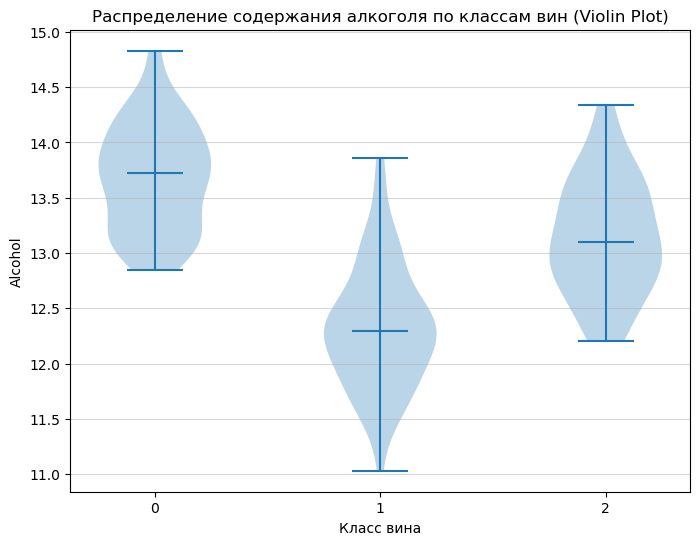

In [17]:
plt.figure(figsize=(8, 6))

# Собираем данные по классам
classes = sorted(df['target'].unique())
data_for_violin = [df[df['target'] == c]['alcohol'].values for c in classes]

# Построение violinplot на чистом matplotlib
plt.violinplot(data_for_violin, positions=classes, showmedians=True)

plt.title('Распределение содержания алкоголя по классам вин (Violin Plot)')
plt.xlabel('Класс вина')
plt.ylabel('Alcohol')
plt.xticks(classes)
plt.grid(axis='y', alpha=0.5)
plt.show()

### 5. Выводы

In [16]:
print("""
Выводы:
- Для количественного признака alcohol использована медиана, т.к. она устойчива к выбросам.
- Для категориального признака alcohol_cat — мода, т.к. это наиболее частое значение.
- Для моделирования будут использованы все исходные числовые признаки (alcohol, malic_acid, ...),
  кроме искусственно созданного alcohol_cat, который добавлен только для демонстрации.
- Скрипичная диаграмма показывает заметную разницу в среднем содержании алкоголя
  для классов 0, 1 и 2 (класс 0 в целом имеет более высокие значения).
""")


Выводы:
- Для количественного признака alcohol использована медиана, т.к. она устойчива к выбросам.
- Для категориального признака alcohol_cat — мода, т.к. это наиболее частое значение.
- Для моделирования будут использованы все исходные числовые признаки (alcohol, malic_acid, ...),
  кроме искусственно созданного alcohol_cat, который добавлен только для демонстрации.
- Скрипичная диаграмма показывает заметную разницу в среднем содержании алкоголя
  для классов 0, 1 и 2 (класс 0 в целом имеет более высокие значения).

